## Step:1 Load and datset overview

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Resetting the dataframe path to the original file for future use
new_path = "..\\data\\filter_OHLCV.parquet"
new_parquet_path = Path(new_path)

df = pd.read_parquet(new_parquet_path)
df

,symbol,date,open,high,low,close,volume
0,BRK-B,2016-01-08,130.110001,130.399994,128.210007,128.330002,6101600
1,BRK-B,2016-01-13,128.970001,129.380005,125.709999,126.250000,6042400
2,BRK-B,2016-01-15,125.339996,126.809998,124.510002,126.139999,8145100
3,BRK-B,2016-01-29,126.660004,129.770004,126.110001,129.770004,6523800
4,BRK-B,2016-02-03,126.339996,126.629997,123.550003,126.239998,6607500
...,...,...,...,...,...,...,...
1220273,VICI,2020-07-02,15.681162,15.740225,15.260340,15.400615,4136400
1220274,VICI,2020-07-06,15.799288,15.865734,14.902272,14.928112,4423500
1220275,VICI,2020-07-07,14.691864,15.105303,14.573738,14.758309,2779800
1220276,VICI,2020-07-08,14.809990,14.950265,14.621728,14.913351,2158800


In [6]:
# Set plotting style and figure size
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

# Basic info about the dataset
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nDate range:", df['date'].min(), "→", df['date'].max())
print("Unique stocks:", df['symbol'].nunique())
print("Total trading days per stock (avg):", round(df.groupby('symbol').size().mean(), 1))

Shape: (1220278, 7)

Columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']

Dtypes:
 symbol               str
date      datetime64[ms]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

Date range: 2016-01-04 00:00:00 → 2025-12-31 00:00:00
Unique stocks: 500
Total trading days per stock (avg): 2440.6


## Step:2 Descriptive Statistics

In [8]:
# Overall descriptive statistics for numeric columns
desc = df[['open', 'high', 'low', 'close', 'volume']].describe().T
desc['median'] = df[['open', 'high', 'low', 'close', 'volume']].median()
desc['skewness'] = df[['open', 'high', 'low', 'close', 'volume']].skew()
desc['kurtosis'] = df[['open', 'high', 'low', 'close', 'volume']].kurtosis()
print(desc.round(4))

            count          mean           std     min           25%  \
open    1220278.0  1.291075e+02  2.701225e+02  0.6044  4.132850e+01   
high    1220278.0  1.305998e+02  2.733323e+02  0.6234  4.180040e+01   
low     1220278.0  1.275897e+02  2.670019e+02  0.6037  4.084200e+01   
close   1220278.0  1.291225e+02  2.701622e+02  0.6151  4.133420e+01   
volume  1220278.0  6.553134e+06  2.734128e+07  0.0000  1.022400e+06   

                 50%           75%           max        median  skewness  \
open    7.692130e+01  1.445747e+02  9.914170e+03  7.692130e+01   16.8218   
high    7.780520e+01  1.462170e+02  9.964770e+03  7.780520e+01   16.8095   
low     7.602860e+01  1.429289e+02  9.794000e+03  7.602860e+01   16.8411   
close   7.692330e+01  1.445894e+02  9.924400e+03  7.692330e+01   16.8152   
volume  2.191900e+06  5.073200e+06  3.692928e+09  2.191900e+06   24.5832   

         kurtosis  
open     402.6240  
high     401.7632  
low      403.5868  
close    402.1954  
volume  1121.516

In [7]:
# Per symbol Stats: avg closing price and volume, volatility (std of close), and trading frequency
symbol_stats = df.groupby('symbol').agg(
    avg_close=('close', 'mean'),
    std_close=('close', 'std'),
    avg_volume=('volume', 'mean'),
    trading_days=('date', 'count')
).sort_values('avg_close', ascending=False)

print("Top 10 highest avg price stocks:\n", symbol_stats.head(10))
print("\nTop 10 most traded stocks:\n", symbol_stats.sort_values('avg_volume', ascending=False).head(10))

Top 10 highest avg price stocks:
           avg_close    std_close    avg_volume  trading_days
symbol                                                      
NVR     4500.626078  2110.743117  2.487164e+04          2514
AZO     1724.514482  1034.008336  2.431223e+05          2514
MTD      970.290890   384.229421  1.517589e+05          2514
FICO     622.465237   577.286522  2.181589e+05          2514
BLK      576.834122   237.381403  6.688143e+05          2514
EQIX     567.331233   190.378787  5.246917e+05          2514
REGN     559.376094   201.568270  8.258362e+05          2514
TDG      552.810008   375.574751  4.054009e+05          2514
GWW      479.170514   297.123284  4.506095e+05          2514
COST     417.016592   270.743601  2.343027e+06          2514

Top 10 most traded stocks:
          avg_close   std_close    avg_volume  trading_days
symbol                                                    
NVDA     36.044211   51.193296  4.588549e+08          2514
TSLA    149.732458  131.0163

## Step:3 Missing Values Analysis


        Missing Count  Missing %
symbol              0        0.0
date                0        0.0
open                0        0.0
high                0        0.0
low                 0        0.0
close               0        0.0
volume              0        0.0
No missing values found.

Stocks with <90% date coverage: 30
symbol
Q         46
SNDK     222
GEV      443
SOLV     444
VLTO     563
KVUE     668
GEHC     763
CEG      992
HOOD    1112
APP     1185
Name: date, dtype: int64


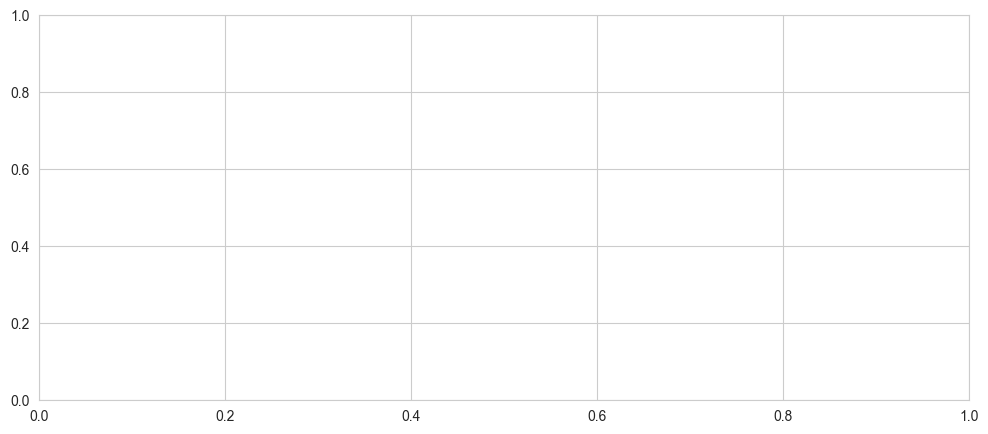

In [8]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(4)
})
print(missing_df)

# Plot only columns that actually have missing values
fig, ax = plt.subplots()
missing_to_plot = missing_pct[missing_pct > 0]

if len(missing_to_plot) > 0:
    missing_to_plot.plot(kind='bar', ax=ax, color='salmon')
    ax.set_title('Missing Value Percentage by Column')
    ax.set_ylabel('% Missing')
    ax.set_xlabel('Column')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

# Checking for stocks with incomplete date coverage
expected_days = df['date'].nunique()
stock_coverage = df.groupby('symbol')['date'].count()
incomplete_stocks = stock_coverage[stock_coverage < expected_days * 0.9]

print(f"\nStocks with <90% date coverage: {len(incomplete_stocks)}")
print(incomplete_stocks.sort_values().head(10))

## Step:4 Outlier Detection

In [9]:
# IQR method to count outliers in each numeric column
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

for col in ['open', 'high', 'low', 'close', 'volume']:
    n = count_outliers_iqr(df[col])
    print(f"{col}: {n} outliers ({n/len(df)*100:.2f}%)")

open: 90989 outliers (7.46%)
high: 91150 outliers (7.47%)
low: 90740 outliers (7.44%)
close: 90988 outliers (7.46%)
volume: 127161 outliers (10.42%)


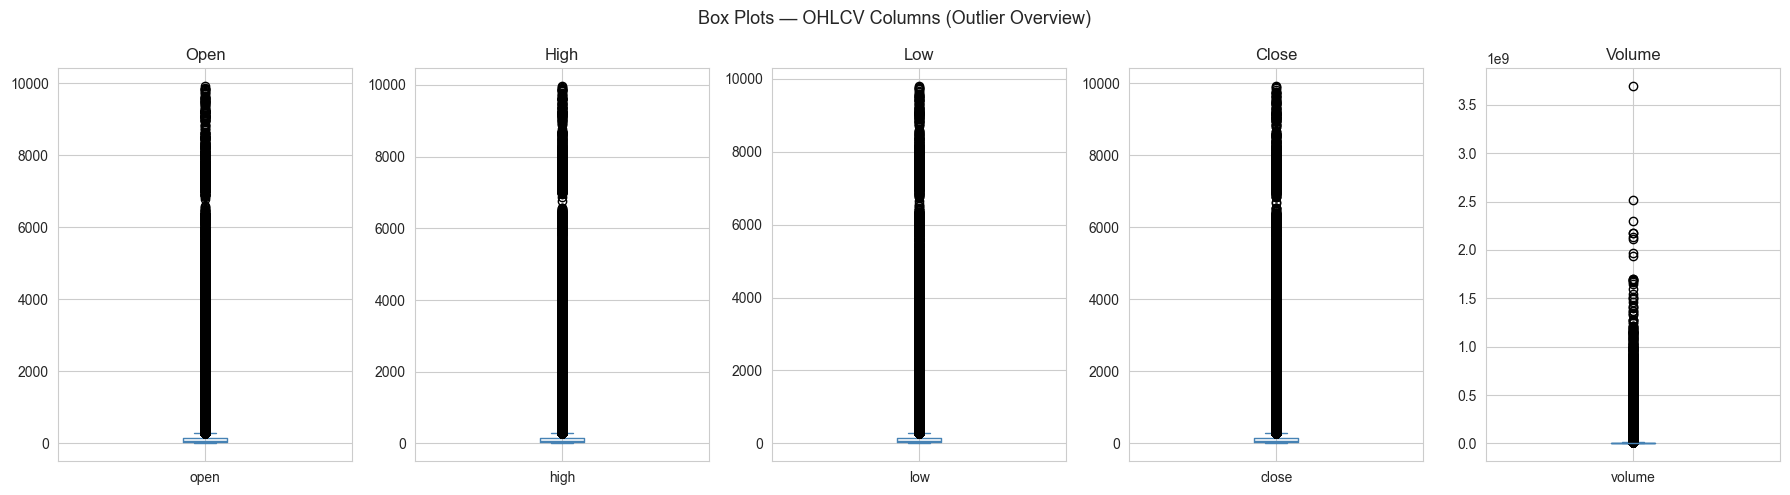

In [10]:
# Box plots for OHLCV columns to visualize outliers
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, ['open', 'high', 'low', 'close', 'volume']):
    df[col].plot(kind='box', ax=ax, color='steelblue')
    ax.set_title(col.capitalize())
    ax.set_xlabel('')
plt.suptitle('Box Plots — OHLCV Columns (Outlier Overview)', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# Data integrity check: high >= low, high >= close, etc.
invalid_hl = (df['high'] < df['low']).sum()
invalid_hc = (df['high'] < df['close']).sum()
invalid_lo = (df['low'] > df['open']).sum()
print(f"Rows where high < low: {invalid_hl}")
print(f"Rows where high < close: {invalid_hc}")
print(f"Rows where low > open: {invalid_lo}")

Rows where high < low: 0
Rows where high < close: 109
Rows where low > open: 1


## Step:5 Distribution Analysis

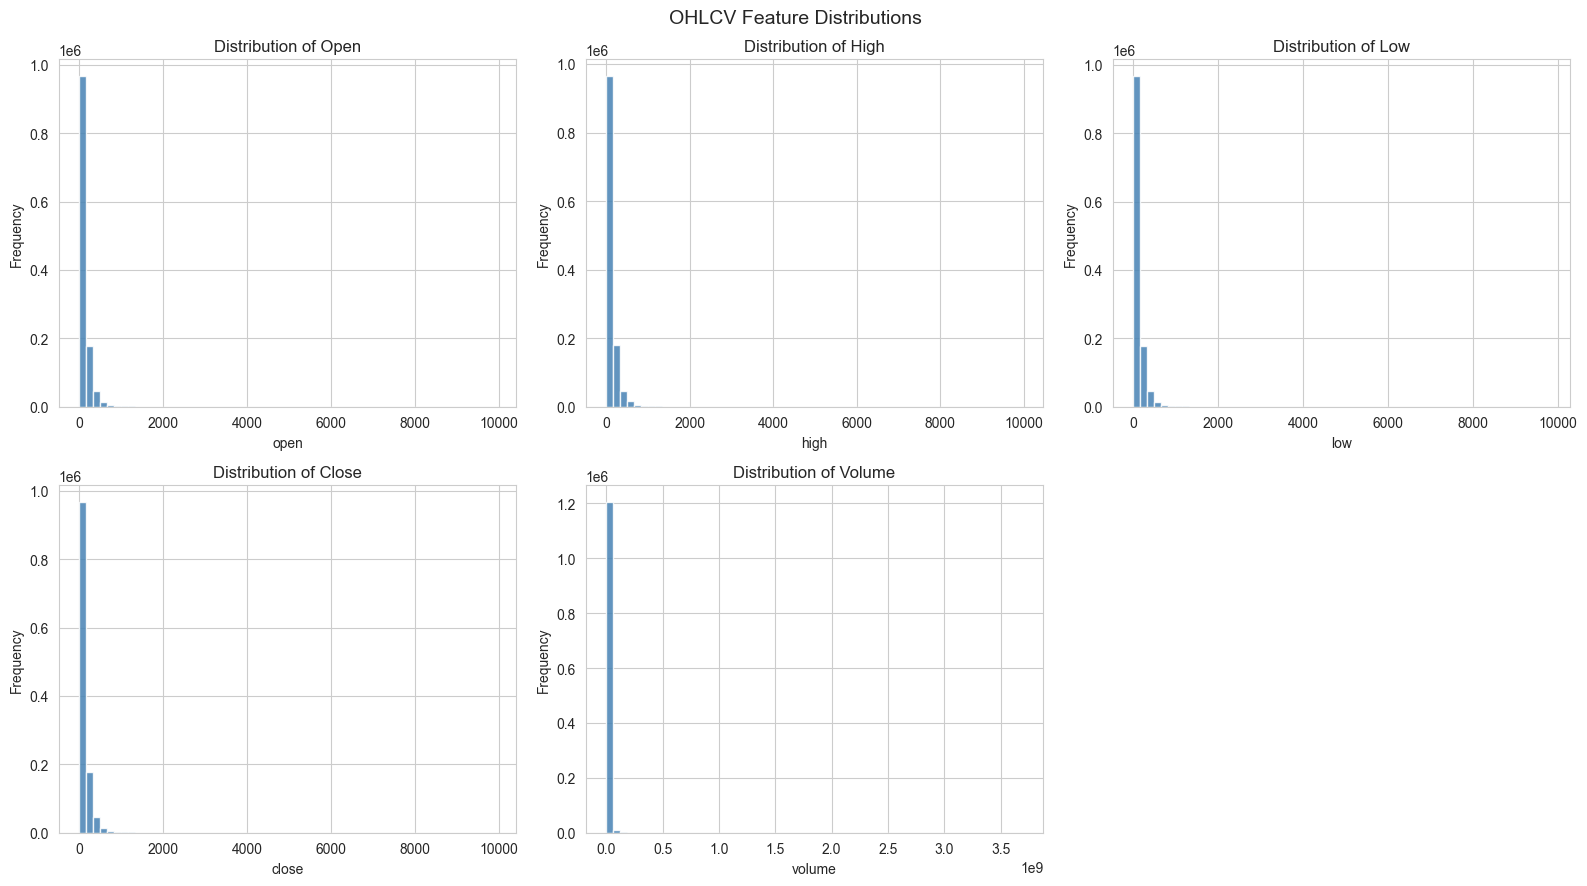

In [12]:
# Histograms for OHLCV columns to visualize distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(['open', 'high', 'low', 'close', 'volume']):
    axes[i].hist(df[col].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col.capitalize()}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
axes[-1].set_visible(False)
plt.suptitle('OHLCV Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Step:6 Correlation & Relationship Analysis

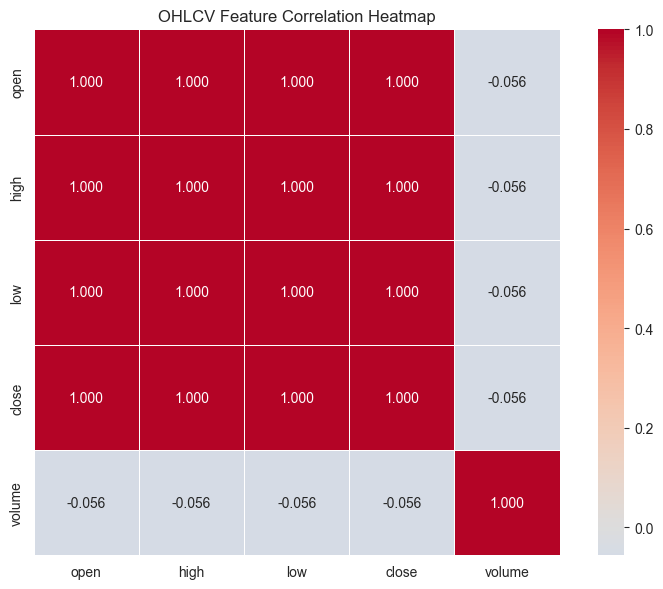


Interpretation: Open/High/Low/Close are strongly correlated (multicollinearity risk).
Volume has weaker correlation - may be a useful independent signal.


In [13]:
# Correlation heatmap for OHLCV features
corr = df[['open', 'high', 'low', 'close', 'volume']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('OHLCV Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
print("\nInterpretation: Open/High/Low/Close are strongly correlated (multicollinearity risk).")
print("Volume has weaker correlation - may be a useful independent signal.")

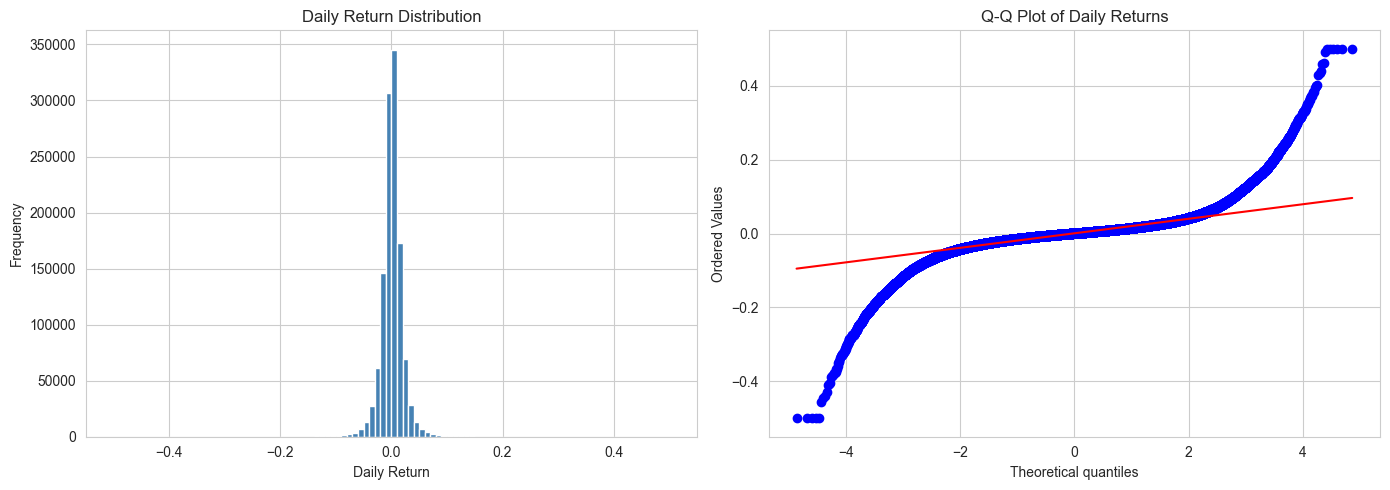

Skewness: 0.1919
Kurtosis: 25.6717


In [14]:
# Daily return distribution and Q-Q plot
df = df.sort_values(['symbol', 'date'])
df['daily_return'] = df.groupby('symbol')['close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['daily_return'].dropna().clip(-0.5, 0.5).plot(
    kind='hist', bins=100, ax=axes[0], color='steelblue')
axes[0].set_title('Daily Return Distribution')
axes[0].set_xlabel('Daily Return')

stats.probplot(df['daily_return'].dropna().clip(-0.5, 0.5), plot=axes[1])
axes[1].set_title('Q-Q Plot of Daily Returns')
plt.tight_layout()
plt.show()

print("Skewness:", round(df['daily_return'].skew(), 4))
print("Kurtosis:", round(df['daily_return'].kurtosis(), 4))

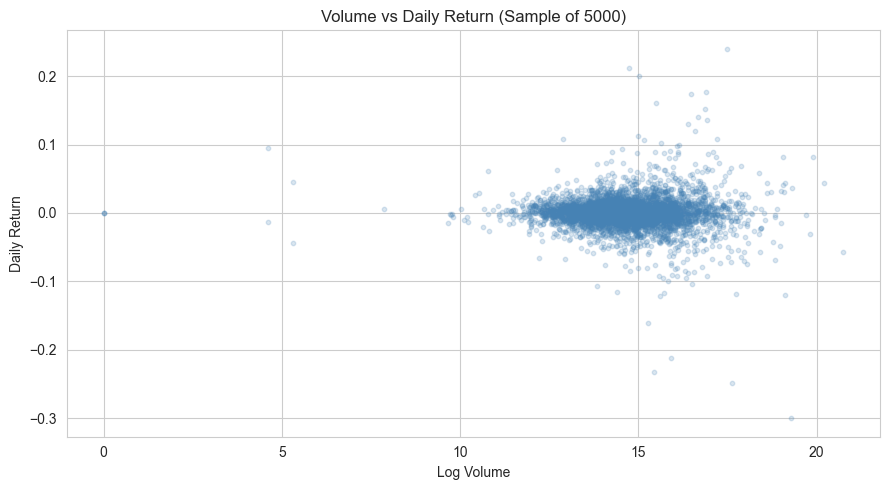

In [15]:
# Scatter plot of volume vs daily return (using a sample for clarity)
sample = df[['volume', 'daily_return']].dropna().sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(np.log1p(sample['volume']), sample['daily_return'].clip(-0.3, 0.3),
           alpha=0.2, s=10, color='steelblue')
ax.set_xlabel('Log Volume')
ax.set_ylabel('Daily Return')
ax.set_title('Volume vs Daily Return (Sample of 5000)')
plt.tight_layout()
plt.show()

## Step:7 Time Series Trend Analysis

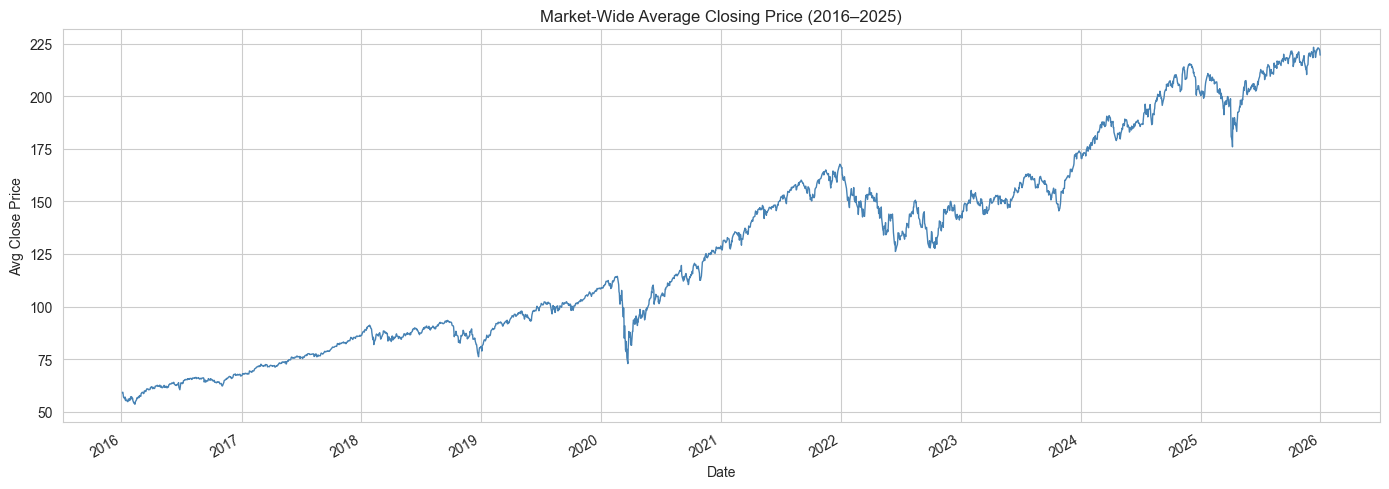

In [16]:
# Market-wide average closing price over time
daily_avg = df.groupby('date')['close'].mean()
fig, ax = plt.subplots(figsize=(14, 5))
daily_avg.plot(ax=ax, color='steelblue', linewidth=1)
ax.set_title('Market-Wide Average Closing Price (2016–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Close Price')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

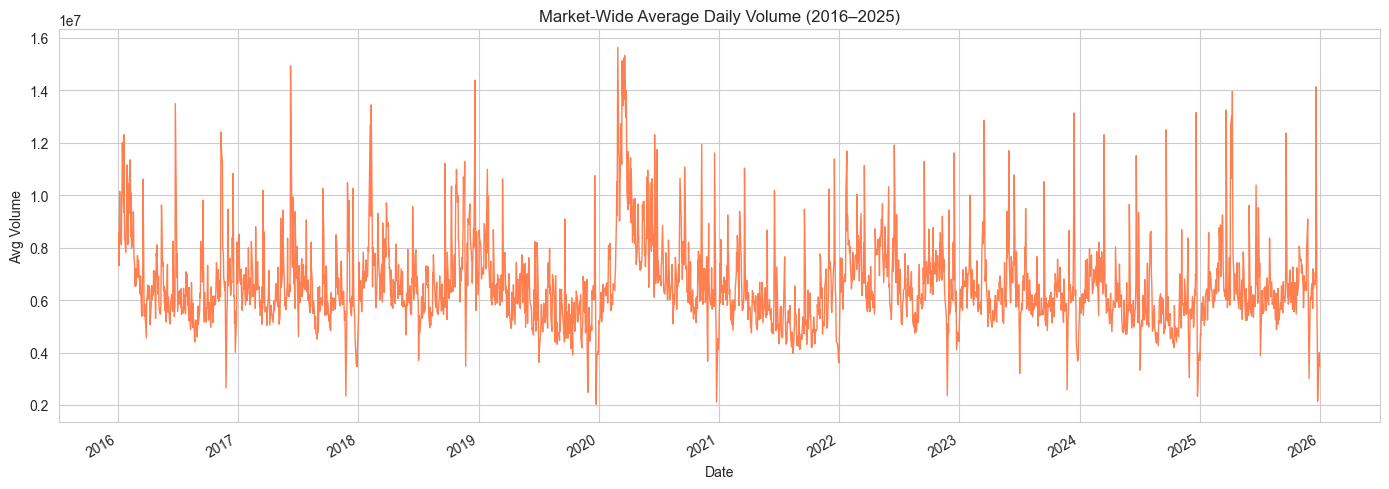

In [17]:
# Average daily volume over time
daily_vol = df.groupby('date')['volume'].mean()
fig, ax = plt.subplots(figsize=(14, 5))
daily_vol.plot(ax=ax, color='coral', linewidth=1)
ax.set_title('Market-Wide Average Daily Volume (2016–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Volume')
plt.tight_layout()
plt.show()

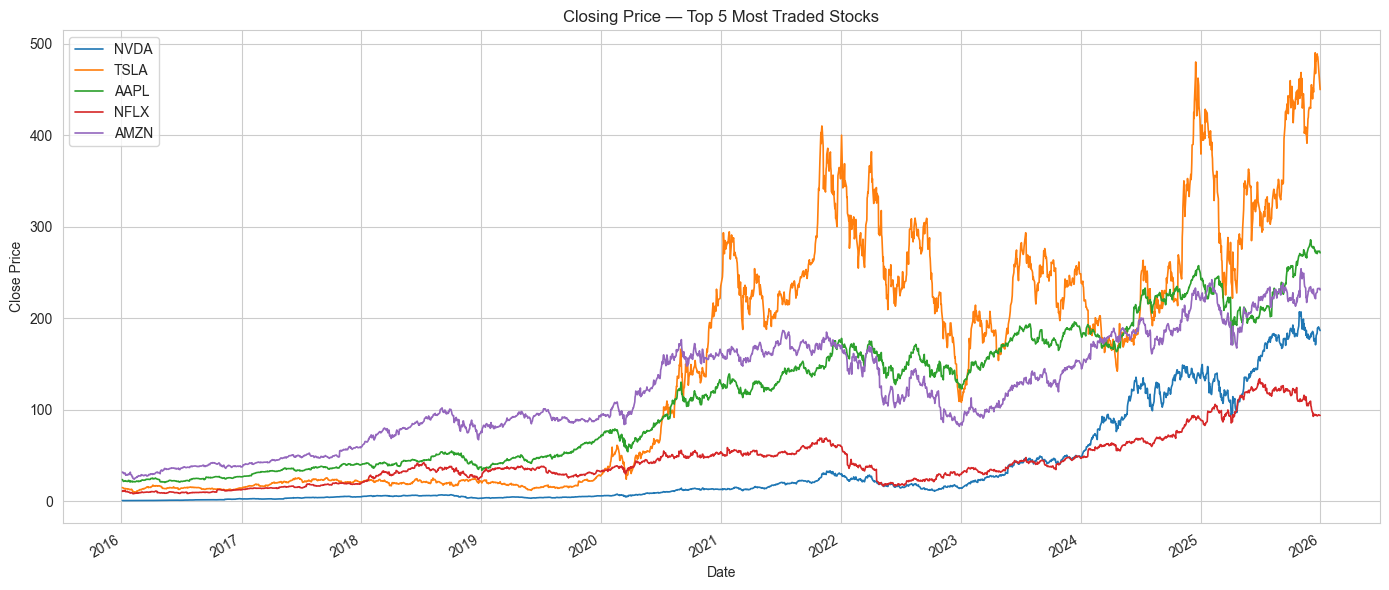

In [18]:
# Price trend for top 5 stocks by avg volume
top5 = symbol_stats.sort_values('avg_volume', ascending=False).head(5).index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
for sym in top5:
    subset = df[df['symbol'] == sym].set_index('date')['close']
    subset.plot(ax=ax, label=sym, linewidth=1.2)
ax.set_title('Closing Price — Top 5 Most Traded Stocks')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price')
ax.legend()
plt.tight_layout()
plt.show()

## Step:8 Market Volatility Analysis

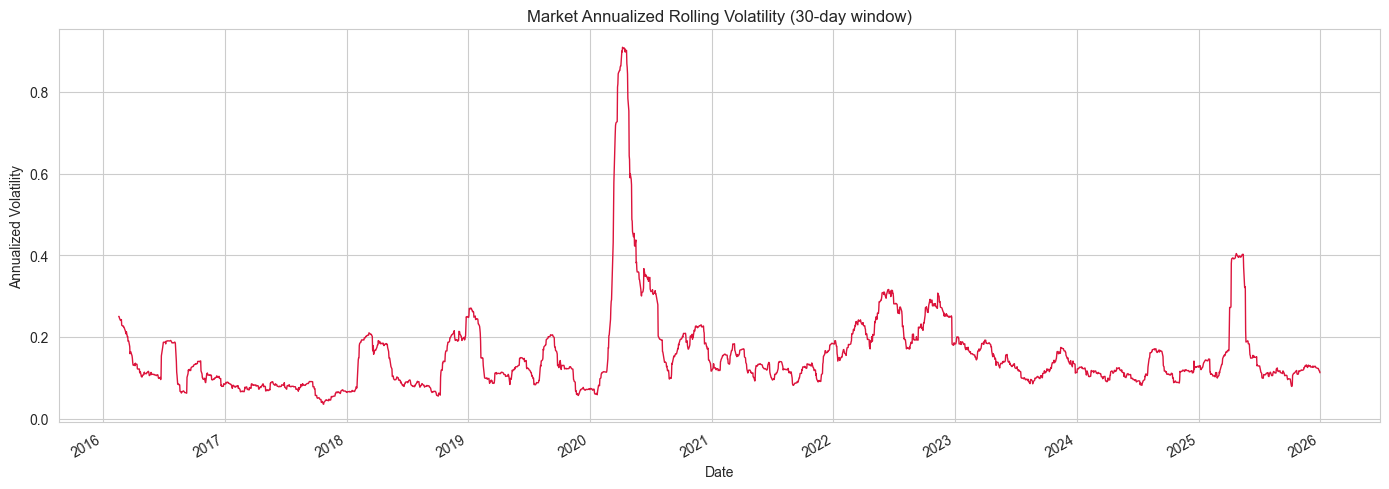

In [19]:
# Rolling volatility of the market (using daily returns)
market_returns = df.groupby('date')['daily_return'].mean()
rolling_vol = market_returns.rolling(30).std() * np.sqrt(252)  # annualized

fig, ax = plt.subplots(figsize=(14, 5))
rolling_vol.plot(ax=ax, color='crimson', linewidth=1)
ax.set_title('Market Annualized Rolling Volatility (30-day window)')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility')
plt.tight_layout()
plt.show()
# This should clearly show 2020 COVID spike and other market events

## Step:9 Class Distribution/Target Variable analysis

Class distribution:
 target
1.0    0.5241
0.0    0.4759
Name: proportion, dtype: float64


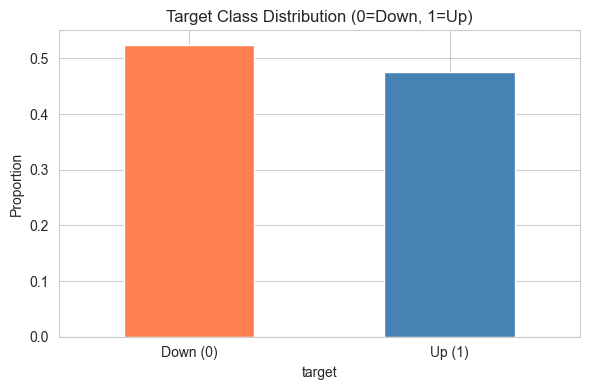

In [20]:
# Define the target variable: 1 if next day's close is higher than today's, else 0
df['target'] = (df.groupby('symbol')['close'].shift(-1) > df['close']).astype(float)

class_dist = df['target'].value_counts(normalize=True)
print("Class distribution:\n", class_dist.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
class_dist.plot(kind='bar', ax=ax, color=['coral', 'steelblue'])
ax.set_title('Target Class Distribution (0=Down, 1=Up)')
ax.set_xticklabels(['Down (0)', 'Up (1)'], rotation=0)
ax.set_ylabel('Proportion')
plt.tight_layout()
plt.show()

## Step:10 Data Quality Summary

In [21]:
# Summary Table

print("DATA QUALITY SUMMARY")
print("")
print(f"Total records:          {len(df):,}")
print(f"Unique stocks:          {df['symbol'].nunique()}")
print(f"Date range:             {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Missing values (any):   {df.isnull().any(axis=1).sum():,}")
print(f"Duplicate rows:         {df.duplicated().sum():,}")
print(f"Invalid OHLC rows:      {(df['high'] < df['low']).sum():,}")
print(f"Stocks w/ <90% cover:   {len(incomplete_stocks)}")

DATA QUALITY SUMMARY

Total records:          1,220,278
Unique stocks:          500
Date range:             2016-01-04 -> 2025-12-31
Missing values (any):   500
Duplicate rows:         0
Invalid OHLC rows:      0
Stocks w/ <90% cover:   30
